# Clinical Supply Chain (CSC) — BDI Pipeline Walkthrough

This notebook walks through the **BDI (Belief-Desire-Intention) supply chain planning pipeline** end-to-end:
from loading synthetic clinical trial data, through the 5 BDI agents, to inspecting
every output — with deep dives into beliefs, goals, plan selection, and execution.

The BDI pipeline is a **drop-in replacement** for the LLM and RL pipelines. All three produce
identical Pydantic model outputs and write to the same `SharedState` blackboard.

---

## System Architecture

```
┌───────────────────────────────────────────────────────────────────┐
│                   BDI SUPPLY CHAIN PIPELINE                       │
│                   (with iterative replanning)                     │
│                                                                   │
│  JSON Data Files                                                  │
│  (trials, sites,  ──▶ SharedState Blackboard                     │
│   plants, depots,      (in-memory, read/write by all agents)     │
│   materials, ...)      │                                        │
│                        │                                        │
│                        ▼                                        │
│              ┌─────────────────┐                                │
│              │  BDI Agent 1    │  Demand Review                  │
│              │  DemandPlan     │  beliefs -> goals -> plans      │
│              └────────┬────────┘  3 desires, 3 plans             │
│                       │                                        │
│                       ▼                                        │
│              ┌─────────────────┐                                │
│              │  BDI Agent 2    │  Portfolio Review               │
│              │  PortfolioPlan  │  trial ranking + conflicts      │
│              └────────┬────────┘  4 desires, 4 plans             │
│                       │                                        │
│                       ▼                                        │
│              ┌─────────────────┐                                │
│              │  BDI Agent 3    │  Supply Review                  │
│              │  SupplyPlan     │  BOM + backward scheduling      │
│              └────────┬────────┘  5 desires, 5 plans             │
│                       │                                        │
│                       ▼                                        │
│              ┌─────────────────┐                                │
│              │  BDI Agent 4    │  Depot Capacity                 │
│              │  DepotCapPlan   │  packaging + labeling           │
│              └────────┬────────┘  5 desires, 5 plans             │
│                       │                                        │
│                       ▼                                        │
│              ┌─────────────────┐                                │
│              │  BDI Agent 5    │  Plant Capacity                 │
│              │  PlantCapPlan   │  reactor + formulation          │
│              └─────────────────┘  5 desires, 5 plans             │
│                       │                                        │
│                       ▼                                        │
│              ┌─────────────────┐                                │
│              │ Feasible?       │── YES ─▶ Done                  │
│              └────────┬────────┘                                │
│                       │ NO                                    │
│                       ▼                                        │
│              Inject capacity constraints                        │
│              Re-run all 5 agents (max 2 retries)                │
└───────────────────────────────────────────────────────────────────┘
```

**Key difference from LLM/RL pipelines:** Each BDI agent uses a structured
reasoning cycle (Beliefs → Desires → Intentions) with explicit goal hierarchies
and plan libraries. No API keys or pre-trained models are needed — all logic is
rule-based and fully interpretable.

## 0. Setup

In [1]:
import os, sys
from pathlib import Path

# Ensure the repo root is on the path so `csc` is importable
REPO_ROOT = Path(os.getcwd()).parent if "notebooks" in os.getcwd() else Path(os.getcwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

DATA_DIR = REPO_ROOT / "src" / "csc" / "data" / "output"

print(f"Repo root: {REPO_ROOT}")
print(f"Data dir:  {DATA_DIR}")

Repo root: c:\Users\Ferhat\Documents\GitHub\csc-skill-test
Data dir:  c:\Users\Ferhat\Documents\GitHub\csc-skill-test\src\csc\data\output


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from csc.config import Config
from csc.orchestrator.state import SharedState
from csc.orchestrator.bdi_pipeline import BDISupplyChainPipeline, BDI_AGENT_SEQUENCE, MAX_REPLANS

# BDI framework internals
from csc.bdi.beliefs import Belief, BeliefBase
from csc.bdi.desires import Desire, GoalHierarchy, GoalStatus
from csc.bdi.intentions import Plan, PlanLibrary, IntentionStack
from csc.bdi.base_agent import BaseBDIAgent

# BDI agent implementations
from csc.bdi.agents.demand_agent import DemandBDIAgent
from csc.bdi.agents.portfolio_agent import PortfolioBDIAgent
from csc.bdi.agents.supply_agent import SupplyBDIAgent
from csc.bdi.agents.depot_agent import DepotCapacityBDIAgent
from csc.bdi.agents.plant_agent import PlantCapacityBDIAgent

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

---

## 1. Load Reference Data

Load synthetic clinical supply chain data into `SharedState` — the same blackboard
used by the LLM, RL, and BDI pipelines.

In [3]:
state = SharedState()
state.load_from_dir(DATA_DIR)

print("=== Reference Data Summary ===")
print(f"  Trials:               {len(state.trials)}")
print(f"  Clinical sites:       {len(state.sites)}")
print(f"  Plants:               {len(state.plants)}")
print(f"  Depots:               {len(state.depots)}")
print(f"  Equipment lines:      {len(state.equipment_lines)}")
print(f"  Changeover rules:     {len(state.changeover_rules)}")
print(f"  Enrollment forecasts: {len(state.enrollment_forecasts)}")
print(f"  Inventory positions:  {len(state.inventory_positions)}")
print(f"  Drug substances:      {len(state.materials.drug_substances)}")
print(f"  Drug products:        {len(state.materials.drug_products)}")
print(f"  Primary packs:        {len(state.materials.primary_packs)}")
print(f"  Finished goods:       {len(state.materials.finished_goods)}")

=== Reference Data Summary ===
  Trials:               15
  Clinical sites:       30
  Plants:               2
  Depots:               6
  Equipment lines:      31
  Changeover rules:     35
  Enrollment forecasts: 2627
  Inventory positions:  60
  Drug substances:      15
  Drug products:        15
  Primary packs:        15
  Finished goods:       15


---

## 2. Run the Full BDI Pipeline

`BDISupplyChainPipeline` mirrors the LLM and RL pipelines but uses BDI reasoning.
The 5 agents run sequentially, each reading upstream outputs from SharedState:

1. **Demand Review** — forecasts enrollment and computes kit demand per trial-site pair
2. **Portfolio Review** — ranks trials, detects conflicts and synergies
3. **Supply Review** — explodes BOMs, schedules batches backward from demand dates
4. **Depot Capacity** — validates packaging and labeling capacity at depots
5. **Plant Capacity** — validates manufacturing capacity at pilot plants

After all 5 agents run, if either capacity plan is infeasible, the pipeline
injects constraints and re-runs all agents (up to `MAX_REPLANS=2` retries).

In [4]:
config = Config(method="bdi")
pipeline = BDISupplyChainPipeline(config)
pipeline.load_data(DATA_DIR)
final_state = pipeline.run_full()

Loaded data from c:\Users\Ferhat\Documents\GitHub\csc-skill-test\src\csc\data\output

Running BDI Supply Chain Pipeline

============================================================

  Demand Review (BDI Agent)

============================================================

...

-> Done

All goals achieved in 4 cycle(s)

Result: feasible=False, 4 bottlenecks, 1 adjustments

[OK] BDI plant_capacity completed

Max replanning attempts (2) reached — proceeding with infeasible plan

In [5]:
# Verify all agent outputs are populated
output_keys = ["demand_plan", "portfolio_plan", "supply_plan", "depot_capacity_plan", "plant_capacity_plan"]
print("=== Pipeline Outputs ===")
for key in output_keys:
    val = final_state.get(key)
    status = type(val).__name__ if val is not None else "NOT SET"
    print(f"  {key:30s} -> {status}")

print(f"\n  Pipeline events logged: {len(final_state.events)}")
for ev in final_state.events:
    print(f"    [{ev.event_type:10s}] {ev.agent_name}: {ev.message}")

=== Pipeline Outputs ===
  demand_plan                    -> DemandPlan
  portfolio_plan                 -> PortfolioPlan
  supply_plan                    -> SupplyPlan
  depot_capacity_plan            -> DepotCapacityPlan
  plant_capacity_plan            -> PlantCapacityPlan

  Pipeline events logged: 30
    [started   ] demand_review: BDI demand_review agent starting
    [completed ] demand_review: BDI demand_review produced output
    [started   ] portfolio_review: BDI portfolio_review agent starting
    [completed ] portfolio_review: BDI portfolio_review produced output
    [started   ] supply_review: BDI supply_review agent starting
    [completed ] supply_review: BDI supply_review produced output
    [started   ] depot_capacity: BDI depot_capacity agent starting
    [completed ] depot_capacity: BDI depot_capacity produced output
    [started   ] plant_capacity: BDI plant_capacity agent starting
    [completed ] plant_capacity: BDI plant_capacity produced output
    [started   ] d

---

## 3. BDI Framework Internals

Before diving into each agent, let's explore the core BDI building blocks:

| Component | Class | Role |
|-----------|-------|------|
| **Beliefs** | `BeliefBase` | World model — facts loaded from SharedState + computed values |
| **Desires** | `GoalHierarchy` | Prioritized goals with satisfaction conditions |
| **Intentions** | `IntentionStack` + `PlanLibrary` | Committed plans selected from a library |

The BDI reasoning cycle repeats:
1. **Deliberation** — update goal statuses from beliefs
2. **Plan selection** — find applicable plans for active goals
3. **Execution** — run plan bodies, updating beliefs
4. **Re-check** — if all goals achieved, stop; else repeat

In [6]:
# --- BeliefBase: the agent's world model ---
bb = BeliefBase()

# Set beliefs manually
bb.set("total_trials", 15, source="shared_state")
bb.set("demand_compiled", False, source="computed")
bb.set("kit_count", 33005, source="computed")

print("=== BeliefBase Demo ===")
print(f"  total_trials = {bb.get('total_trials')} (has: {bb.has('total_trials')})")
print(f"  demand_compiled = {bb.get('demand_compiled')}")
print(f"  kit_count = {bb.get('kit_count')}")
print(f"  missing_key = {bb.get('missing_key')} (has: {bb.has('missing_key')})")

# Show all stored beliefs
print(f"\n  All beliefs:")
for name, belief in bb.beliefs.items():
    print(f"    {name}: value={belief.value}, source={belief.source}, confidence={belief.confidence}")

=== BeliefBase Demo ===
  total_trials = 15 (has: True)
  demand_compiled = False
  kit_count = 33005
  missing_key = None (has: False)

  All beliefs:
    total_trials: value=15, source=shared_state, confidence=1.0
    demand_compiled: value=False, source=computed, confidence=1.0
    kit_count: value=33005, source=computed, confidence=1.0


In [7]:
# --- GoalHierarchy: prioritized desires with satisfaction conditions ---
gh = GoalHierarchy()

# Define 3 goals with decreasing priority
gh.desires = [
    Desire(
        name="forecast_enrollment",
        priority=1,
        description="All trials have enrollment data",
        is_satisfied=lambda bb: bb.has("enrollment_data"),
    ),
    Desire(
        name="compute_kit_demand",
        priority=2,
        description="Kit demands computed for all trials",
        is_satisfied=lambda bb: bb.get("kit_count") is not None and bb.get("kit_count") > 0,
    ),
    Desire(
        name="compile_plan",
        priority=3,
        description="Final demand plan aggregated",
        is_satisfied=lambda bb: bb.get("demand_compiled") is True,
    ),
]

print("=== GoalHierarchy Demo ===")
print(f"  Total desires: {len(gh.desires)}")

# Check which goals are active (not yet satisfied)
gh.update_statuses(bb)  # bb from previous cell has kit_count=33005 but no enrollment_data
active = gh.active_desires()
print(f"  Active goals: {len(active)}")
for d in gh.desires:
    print(f"    [{d.status.value:8s}] P{d.priority} {d.name}: {d.description}")

=== GoalHierarchy Demo ===
  Total desires: 3
  Active goals: 2
    [active  ] P1 forecast_enrollment: All trials have enrollment data
    [achieved] P2 compute_kit_demand: Kit demands computed for all trials
    [active  ] P3 compile_plan: Final demand plan aggregated


In [8]:
# --- PlanLibrary + IntentionStack: plan selection and execution ---
pl = PlanLibrary()

# Define plan templates with context conditions
pl.plans = [
    Plan(
        name="plan_forecast",
        goal_name="forecast_enrollment",
        context_condition=lambda bb: bb.has("total_trials"),  # need trials loaded
        body=lambda bb, agent: bb.set("enrollment_data", {"trial_1": [10, 20, 30]}),
    ),
    Plan(
        name="plan_kit_demand",
        goal_name="compute_kit_demand",
        context_condition=lambda bb: bb.has("enrollment_data"),  # need enrollment first
        body=lambda bb, agent: bb.set("kit_count", 5000),
    ),
]

print("=== PlanLibrary Demo ===")
print(f"  Total plans: {len(pl.plans)}")

# Find applicable plans for the active goal
applicable = pl.applicable_plans("forecast_enrollment", bb)
print(f"  Applicable plans for 'forecast_enrollment': {[p.name for p in applicable]}")

# Push to intention stack and execute
istack = IntentionStack()
for p in applicable:
    istack.push(p)
    print(f"  Pushed: {p.name}")

print(f"  Stack empty? {istack.is_empty()}")
plan = istack.pop()
print(f"  Popped: {plan.name}")
plan.body(bb, None)  # execute plan body
print(f"  After execution: enrollment_data = {bb.get('enrollment_data')}")

=== PlanLibrary Demo ===
  Total plans: 2
  Applicable plans for 'forecast_enrollment': ['plan_forecast']
  Pushed: plan_forecast
  Stack empty? False
  Popped: plan_forecast
  After execution: enrollment_data = {'trial_1': [10, 20, 30]}


---

## 4. Deep Dive: Demand Review Agent

The demand agent forecasts enrollment and computes kit demand per trial-site pair.

| Desire | Priority | Description |
|--------|----------|-------------|
| `forecast_all_enrollment` | 1 | Group enrollment forecasts by trial |
| `compute_all_kit_demand` | 2 | Compute kits with overage + safety stock |
| `compile_demand_plan` | 3 | Aggregate into final DemandPlan |

**Kit demand formula:**
- `base_kits = active_patients * kits_per_month * kits_per_visit`
- `with_overage = ceil(base_kits * (1 + trial.overage_pct))`
- `safety_stock = ceil(base_kits * safety_months * 0.05)` where safety_months varies by phase:
  - Phase I: 3.0 months
  - Phase II: 2.0 months
  - Phase III: 1.5 months

In [9]:
# Run demand agent step-by-step on a fresh state
demo_state = SharedState()
demo_state.load_from_dir(DATA_DIR)

demand_agent = DemandBDIAgent(demo_state)

# Phase 1: Load and initialize beliefs
demand_agent.belief_base.update_from_state(demo_state, demand_agent.get_input_keys())
demand_agent.initialize_beliefs()

# Phase 2: Define desires and plans
demand_agent.define_desires()
demand_agent.define_plans()

print("=== Demand Agent: Desires ===")
for d in demand_agent.goal_hierarchy.desires:
    satisfied = d.is_satisfied(demand_agent.belief_base)
    print(f"  P{d.priority} [{d.status.value:8s}] {d.name:30s} satisfied={satisfied}")

print(f"\n=== Demand Agent: Plan Library ===")
for p in demand_agent.plan_library.plans:
    ctx_met = p.context_condition(demand_agent.belief_base)
    print(f"  {p.name:35s} goal={p.goal_name:30s} context_met={ctx_met}")

Derived: 15 trial-to-FG mappings

=== Demand Agent: Desires ===
  P1 [active  ] forecast_all_enrollment        satisfied=False
  P2 [active  ] compute_all_kit_demand         satisfied=False
  P3 [active  ] compile_demand_plan            satisfied=False

=== Demand Agent: Plan Library ===
  plan_forecast_enrollment            goal=forecast_all_enrollment        context_met=True
  plan_compute_kit_demand             goal=compute_all_kit_demand         context_met=False
  plan_aggregate                      goal=compile_demand_plan            context_met=False


In [10]:
# Phase 3: Run the BDI reasoning cycle
demand_agent._bdi_cycle()

# Inspect computed beliefs
trial_enrollment = demand_agent.belief_base.get("trial_enrollment")
site_demands = demand_agent.belief_base.get("site_demands")
demand_by_trial = demand_agent.belief_base.get("demand_by_trial")

print(f"\n=== Post-Cycle Beliefs ===")
print(f"  Trials with enrollment data: {len(trial_enrollment)}")
print(f"  Site demand records:         {len(site_demands)}")
print(f"  demand_plan_compiled:        {demand_agent.belief_base.get('demand_plan_compiled')}")

# Show enrollment summary per trial
print(f"\n=== Enrollment by Trial ===")
for protocol, months in list(trial_enrollment.items())[:5]:
    total_new = sum(m.get("new_patients", 0) for m in months)
    peak_active = max((m.get("active", 0) for m in months), default=0)
    print(f"  {protocol}: {len(months)} months, {total_new} new patients, peak active={peak_active}")

# Show demand by trial
print(f"\n=== Kit Demand by Trial ===")
total = 0
for protocol, kits in sorted(demand_by_trial.items(), key=lambda x: -x[1]):
    print(f"  {protocol:20s}: {kits:>8,} kits")
    total += kits
print(f"  {'TOTAL':20s}: {total:>8,} kits")

Cycle 1:

Beliefs: 15 trials, 30 sites, 2627 enrollment_forecasts, 219 patient_cohorts, materials: loaded

Goal: forecast_all_enrollment [ACTIVE]

-> Plan: plan_forecast_enrollment

Result: 15 trials forecasted

...

Goal: compile_demand_plan [ACTIVE]

-> Plan: plan_aggregate

-> Done

All goals achieved in 3 cycle(s)


=== Post-Cycle Beliefs ===
  Trials with enrollment data: 15
  Site demand records:         2627
  demand_plan_compiled:        True

=== Enrollment by Trial ===
  ONCO-2026-001: 22 months, 32 new patients, peak active=19
  ONCO-2026-002: 21 months, 86 new patients, peak active=24
  ONCO-2026-003: 32 months, 489 new patients, peak active=47
  ONCO-2026-004: 35 months, 133 new patients, peak active=48
  IMMU-2026-005: 21 months, 20 new patients, peak active=12

=== Kit Demand by Trial ===
  ONCO-2026-003       :    7,993 kits
  NEUR-2026-011       :    5,109 kits
  IMMU-2026-007       :    5,093 kits
  IMMU-2026-008       :    4,154 kits
  RARE-2026-015       :    2,572 kits
  ONCO-2026-004       :    2,245 kits
  NEUR-2026-012       :    1,354 kits
  NEUR-2026-009       :    1,157 kits
  ONCO-2026-002       :      898 kits
  NEUR-2026-010       :      839 kits
  RARE-2026-014       :      535 kits
  IMMU-2026-006       :      398 kits
  ONCO-2026-001       :      329 kits
  IMMU-2026-

Result: 33,005 total kits across 2627 site-demand records

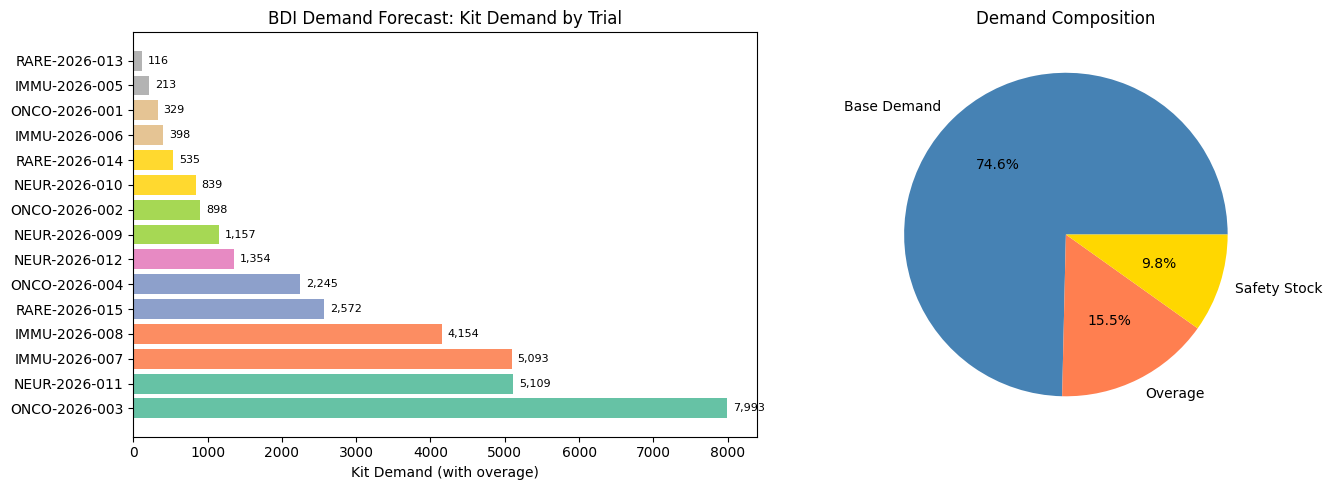

In [11]:
# Build and store the output
demand_plan = demand_agent.build_output()
demo_state.set("demand_plan", demand_plan)

# Plot: Kit demand by trial
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of demand by trial
sorted_demand = sorted(demand_plan.demand_by_trial.items(), key=lambda x: -x[1])
protocols = [p for p, _ in sorted_demand]
kits = [k for _, k in sorted_demand]
colors = plt.cm.Set2(np.linspace(0, 1, len(protocols)))
ax1.barh(protocols, kits, color=colors)
ax1.set_xlabel("Kit Demand (with overage)")
ax1.set_title("BDI Demand Forecast: Kit Demand by Trial")
for i, v in enumerate(kits):
    ax1.text(v + max(kits) * 0.01, i, f"{v:,}", va="center", fontsize=8)

# Pie chart: safety stock vs base demand (site_demands are SiteDemand Pydantic objects)
total_base = sum(sd.quantity_kits for sd in site_demands)
total_safety = sum(sd.safety_stock_kits for sd in site_demands)
total_overage = sum(sd.quantity_with_overage for sd in site_demands) - total_base
ax2.pie(
    [total_base, total_overage, total_safety],
    labels=["Base Demand", "Overage", "Safety Stock"],
    autopct="%1.1f%%",
    colors=["steelblue", "coral", "gold"],
)
ax2.set_title("Demand Composition")

plt.tight_layout()
plt.show()

---

## 5. Deep Dive: Portfolio Review Agent

The portfolio agent ranks trials by strategic priority and detects resource conflicts/synergies.

**Weighted scoring:**
- Phase: 0.35 (Phase III=1.0, II=0.6, I=0.3)
- Therapy area: 0.25 (Oncology=1.0, Rare Disease=0.8, Immunology=0.7, Neuroscience=0.6)
- Timeline urgency: 0.20 (inverse normalized distance to FSFV)
- Enrollment size: 0.20 (normalized by max)

**Conflict detection:**
- Plant conflicts: >3 trials at same plant = medium, >5 = high
- Depot conflicts: >4 trials at same depot region = medium, >8 = high

**Synergies:** shared plants (campaign optimization), shared formulation types (packaging reuse)

In [12]:
# Run portfolio agent
portfolio_agent = PortfolioBDIAgent(demo_state)
portfolio_plan = portfolio_agent.run()

# Show ranked trials
print("=== Trial Rankings ===")
ranking_df = pd.DataFrame(portfolio_plan.ranked_trials)
if "scores" in ranking_df.columns:
    # Expand scores dict into separate columns
    scores_df = pd.json_normalize(ranking_df["scores"])
    ranking_df = pd.concat([ranking_df.drop(columns=["scores"]), scores_df], axis=1)
display(ranking_df)

# Show conflicts
print(f"\n=== Conflicts ({len(portfolio_plan.conflicts)}) ===")
for c in portfolio_plan.conflicts:
    print(f"  [{c.get('severity', 'unknown'):6s}] {c.get('type', '')}: {c.get('resource', c.get('region', ''))}")
    print(f"           Trials: {c.get('trials', [])}")

# Show synergies
print(f"\n=== Synergies ({len(portfolio_plan.synergies)}) ===")
for s in portfolio_plan.synergies:
    print(f"  [{s.get('type', '')}] {s.get('resource', s.get('formulation', ''))}: {s.get('benefit', '')}")

============================================================

  Portfolio Review (BDI Agent)

============================================================

Cycle 1:

Beliefs: 15 trials, demand_plan: loaded, materials: loaded, 2 plants, 6 depots

...

Result: 15 trials ranked, 5 conflicts, 5 synergies

[OK] BDI portfolio_review completed

=== Trial Rankings ===


,protocol,therapy_area,phase,planned_enrollment,total_demand_kits,priority_score,rank,phase,therapy,timeline,enrollment
0,NEUR-2026-011,neuroscience,phase_iii,815,5109,0.900,1,1.0,0.6,1.00,1.00
1,ONCO-2026-003,oncology,phase_iii,610,7993,0.890,2,1.0,1.0,0.70,0.75
2,IMMU-2026-007,immunology,phase_iii,567,5093,0.806,3,1.0,0.7,0.71,0.70
3,RARE-2026-015,rare_disease,phase_iii,196,2572,0.687,4,1.0,0.8,0.44,0.24
4,ONCO-2026-004,oncology,phase_ii,189,2245,0.679,5,0.6,1.0,0.86,0.23
5,ONCO-2026-002,oncology,phase_ii,162,898,0.669,6,0.6,1.0,0.84,0.20
6,IMMU-2026-008,immunology,phase_iii,252,4154,0.628,7,1.0,0.7,0.21,0.31
7,ONCO-2026-001,oncology,phase_i,32,329,0.523,8,0.3,1.0,0.80,0.04
8,IMMU-2026-005,immunology,phase_i,31,213,0.472,9,0.3,0.7,0.92,0.04
9,IMMU-2026-006,immunology,phase_ii,69,398,0.472,10,0.6,0.7,0.35,0.08



=== Conflicts (5) ===
  [high  ] : 
           Trials: []
  [high  ] : 
           Trials: []
  [high  ] : 
           Trials: []
  [high  ] : 
           Trials: []
  [high  ] : 
           Trials: []

=== Synergies (5) ===
  [shared_plant] Springfield Pilot Plant: Campaign scheduling optimization — batch similar products together to minimize changeover
  [shared_plant] Basel Pilot Plant: Campaign scheduling optimization — batch similar products together to minimize changeover
  [shared_formulation] injectable: 8 products use injectable formulation — potential for shared packaging equipment
  [shared_formulation] tablet: 4 products use tablet formulation — potential for shared packaging equipment
  [shared_formulation] lyophilized: 3 products use lyophilized formulation — potential for shared packaging equipment


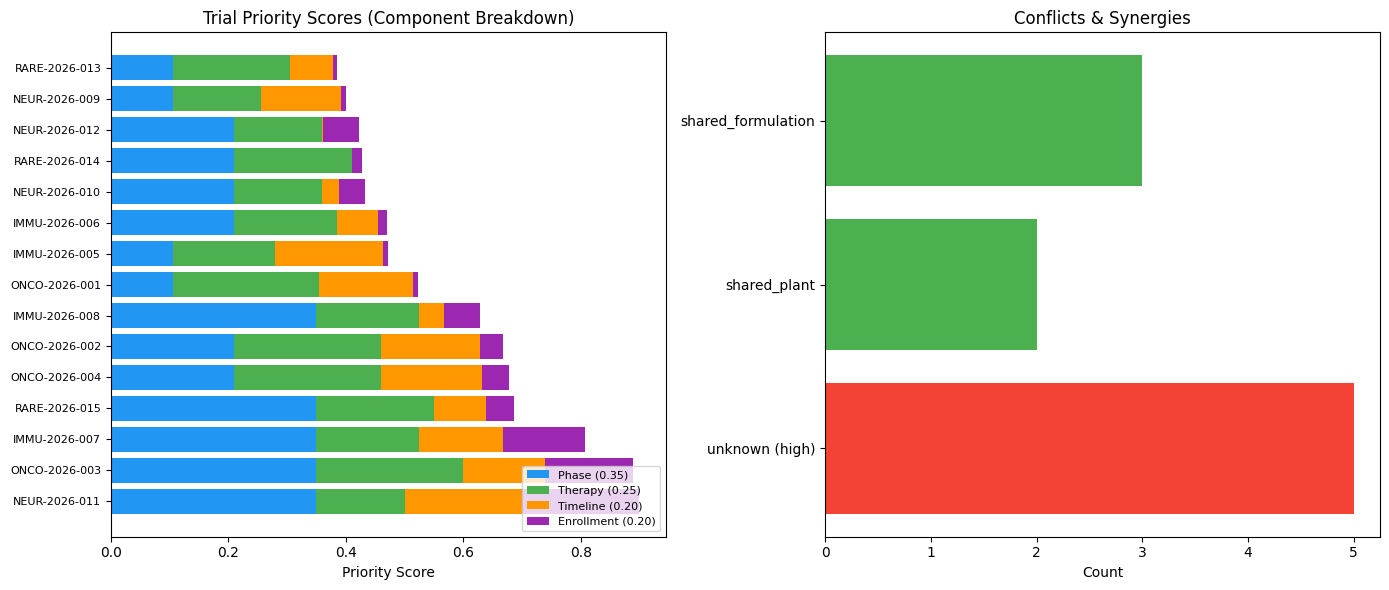

In [13]:
# Plot: Trial priority scores with component breakdown
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Stacked bar: score components
ranked = portfolio_plan.ranked_trials
protocols = [t["protocol"] for t in ranked]
phase_scores = [t.get("scores", {}).get("phase", 0) * 0.35 for t in ranked]
therapy_scores = [t.get("scores", {}).get("therapy", 0) * 0.25 for t in ranked]
timeline_scores = [t.get("scores", {}).get("timeline", 0) * 0.20 for t in ranked]
enrollment_scores = [t.get("scores", {}).get("enrollment", 0) * 0.20 for t in ranked]

y_pos = range(len(protocols))
ax1.barh(y_pos, phase_scores, label="Phase (0.35)", color="#2196F3")
ax1.barh(y_pos, therapy_scores, left=phase_scores, label="Therapy (0.25)", color="#4CAF50")
left2 = [p + t for p, t in zip(phase_scores, therapy_scores)]
ax1.barh(y_pos, timeline_scores, left=left2, label="Timeline (0.20)", color="#FF9800")
left3 = [l + t for l, t in zip(left2, timeline_scores)]
ax1.barh(y_pos, enrollment_scores, left=left3, label="Enrollment (0.20)", color="#9C27B0")
ax1.set_yticks(y_pos)
ax1.set_yticklabels(protocols, fontsize=8)
ax1.set_xlabel("Priority Score")
ax1.set_title("Trial Priority Scores (Component Breakdown)")
ax1.legend(loc="lower right", fontsize=8)

# Conflict and synergy summary
conflict_types = {}
for c in portfolio_plan.conflicts:
    key = f"{c.get('type', 'unknown')} ({c.get('severity', '?')})"
    conflict_types[key] = conflict_types.get(key, 0) + 1
synergy_types = {}
for s in portfolio_plan.synergies:
    key = s.get("type", "unknown")
    synergy_types[key] = synergy_types.get(key, 0) + 1

labels = list(conflict_types.keys()) + list(synergy_types.keys())
values = list(conflict_types.values()) + list(synergy_types.values())
colors_bar = ["#F44336"] * len(conflict_types) + ["#4CAF50"] * len(synergy_types)
if labels:
    ax2.barh(labels, values, color=colors_bar)
    ax2.set_xlabel("Count")
    ax2.set_title("Conflicts & Synergies")
else:
    ax2.text(0.5, 0.5, "No conflicts or synergies", ha="center", va="center", transform=ax2.transAxes)

plt.tight_layout()
plt.show()

---

## 6. Deep Dive: Supply Review Agent

The supply agent is the most complex BDI agent with 5 desires and 5 plans.

**BOM explosion:** FG <- PP (<-1.05 loss) <- DP (<-yield) <- DS

**Backward scheduling** from demand dates:
1. FG labeling + depot-to-site transport
2. PP packaging
3. DP manufacturing + QC + plant-to-depot transport
4. DS manufacturing + QC

**Replanning support:** If `state._bdi_capacity_constraints` is set (from a previous
infeasible run), the supply agent reads these constraints and adjusts batch planning.

In [14]:
# Run supply agent
supply_agent = SupplyBDIAgent(demo_state)
supply_plan = supply_agent.run()

# Inspect BOM beliefs
trial_bom = supply_agent.belief_base.get("trial_bom")
trial_schedule = supply_agent.belief_base.get("trial_schedule")

print("=== BOM Explosion (first 5 trials) ===")
bom_rows = []
for protocol, bom in list(trial_bom.items())[:5]:
    bom_rows.append({
        "protocol": protocol,
        "fg_qty": bom.get("fg_qty", 0),
        "pp_qty": bom.get("pp_qty", 0),
        "dp_qty": bom.get("dp_qty", 0),
        "ds_qty_kg": bom.get("ds_qty_kg", 0),
        "fg_batches": bom.get("fg_batches", 0),
        "pp_batches": bom.get("pp_batches", 0),
        "dp_batches": bom.get("dp_batches", 0),
        "ds_batches": bom.get("ds_batches", 0),
    })
display(pd.DataFrame(bom_rows))

# Backward schedules
print(f"\n=== Backward Schedules (first 5 trials) ===")
sched_rows = []
for protocol, sched in list(trial_schedule.items())[:5]:
    sched_rows.append({
        "protocol": protocol,
        "required_date": str(sched.get("required_date", "")),
        "ds_start": str(sched.get("ds_start", "")),
        "dp_start": str(sched.get("dp_start", "")),
        "pp_start": str(sched.get("pp_start", "")),
        "fg_start": str(sched.get("fg_start", "")),
        "total_lead_days": sched.get("total_lead_days", 0),
    })
display(pd.DataFrame(sched_rows))

============================================================

  Supply Review (BDI Agent)

============================================================

Cycle 1:

Beliefs: demand_plan: loaded, portfolio_plan: loaded, materials: loaded, 60 inventory_positions, 2 plants, 6 
depots, 39 transport_lanes

...

[OK] BDI supply_review completed

=== BOM Explosion (first 5 trials) ===


,protocol,fg_qty,pp_qty,dp_qty,ds_qty_kg,fg_batches,pp_batches,dp_batches,ds_batches
0,ONCO-2026-001,0,0,0,0,0,0,0,0
1,ONCO-2026-002,0,0,0,0,0,0,0,0
2,ONCO-2026-003,0,0,0,0,0,0,0,0
3,ONCO-2026-004,0,0,0,0,0,0,0,0
4,IMMU-2026-005,0,0,0,0,0,0,0,0



=== Backward Schedules (first 5 trials) ===


,protocol,required_date,ds_start,dp_start,pp_start,fg_start,total_lead_days
0,ONCO-2026-001,2026-02-01,2025-09-22,2025-11-27,2026-01-17,2026-01-24,132
1,ONCO-2026-002,2026-01-01,2025-08-22,2025-10-27,2025-12-17,2025-12-24,132
2,ONCO-2026-003,2026-02-01,2025-09-22,2025-11-27,2026-01-17,2026-01-24,132
3,ONCO-2026-004,2026-01-01,2025-08-22,2025-10-27,2025-12-17,2025-12-24,132
4,IMMU-2026-005,2026-01-01,2025-08-22,2025-10-27,2025-12-17,2025-12-24,132


In [15]:
# Batch details
print(f"Total batches: {len(supply_plan.batches)}")
print(f"Horizon: {supply_plan.horizon_start} to {supply_plan.horizon_end}")
print(f"Shortfall alerts: {len(supply_plan.shortfall_alerts)}")

if supply_plan.batches:
    batch_df = pd.DataFrame([
        {
            "batch_number": b.batch_number,
            "stage": b.stage.value,
            "quantity": f"{b.quantity:,.0f}",
            "status": b.status.value,
            "planned_start": str(b.planned_start),
            "planned_end": str(b.planned_end),
        }
        for b in supply_plan.batches[:20]
    ])
    display(batch_df)

    # Batch count by stage
    stage_counts = {}
    for b in supply_plan.batches:
        stage_counts[b.stage.value] = stage_counts.get(b.stage.value, 0) + 1
    print(f"\nBatches by stage:")
    for stage, count in sorted(stage_counts.items()):
        print(f"  {stage}: {count}")

Total batches: 669
Horizon: 2025-08-22 to 2027-03-04
Shortfall alerts: 0


,batch_number,stage,quantity,status,planned_start,planned_end
0,B-DS-ONCO-2026-001-01,ds,23,planned,2025-09-22,2025-11-06
1,B-DS-ONCO-2026-001-02,ds,23,planned,2025-09-25,2025-11-09
2,B-DP-ONCO-2026-001-01,dp,"3,077",planned,2025-11-27,2025-12-27
3,B-DP-ONCO-2026-001-02,dp,"3,077",planned,2025-11-30,2025-12-30
4,B-DP-ONCO-2026-001-03,dp,"3,077",planned,2025-12-03,2026-01-02
5,B-PP-ONCO-2026-001-01,pp,346,planned,2026-01-17,2026-01-24
6,B-FG-ONCO-2026-001-01,fg,329,planned,2026-01-24,2026-01-29
7,B-DS-ONCO-2026-002-01,ds,6,planned,2025-08-22,2025-10-06
8,B-DS-ONCO-2026-002-02,ds,6,planned,2025-08-25,2025-10-09
9,B-DS-ONCO-2026-002-03,ds,6,planned,2025-08-28,2025-10-12



Batches by stage:
  dp: 407
  ds: 232
  fg: 15
  pp: 15


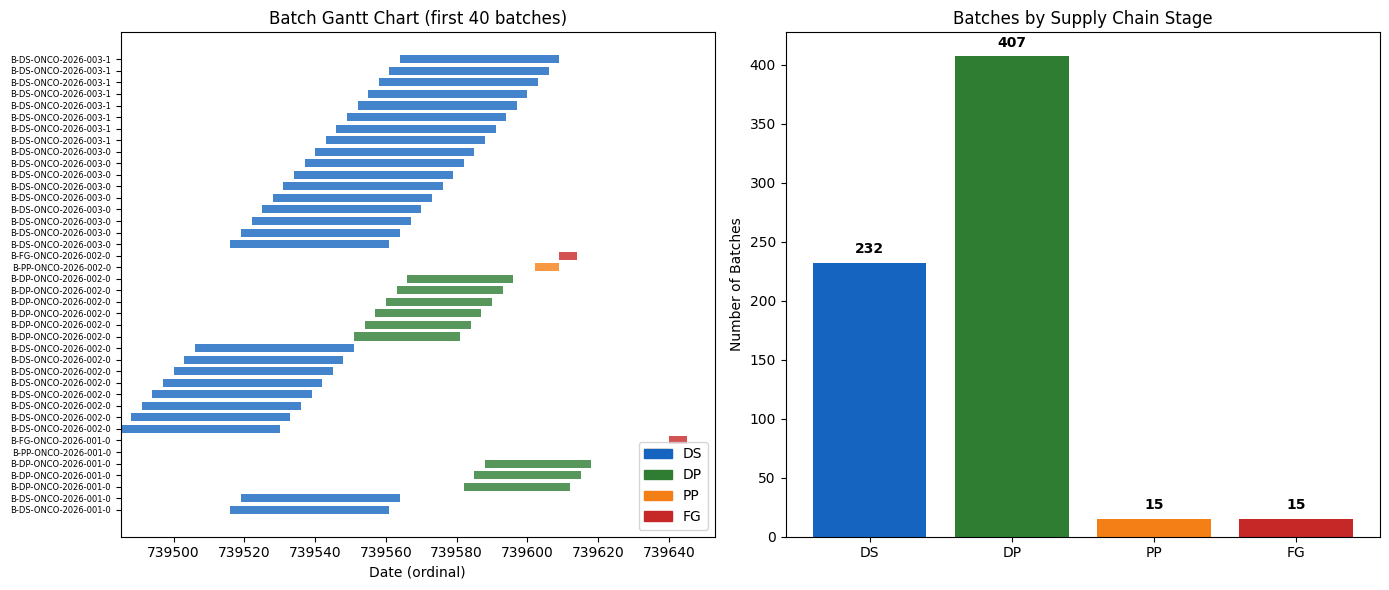

In [16]:
# Plot: Batch Gantt chart and stage distribution
if supply_plan.batches:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Gantt chart (sample of batches)
    stage_colors = {"ds": "#1565C0", "dp": "#2E7D32", "pp": "#F57F17", "fg": "#C62828"}
    sample = supply_plan.batches[:40]
    for i, b in enumerate(sample):
        start = b.planned_start.toordinal()
        end = b.planned_end.toordinal()
        color = stage_colors.get(b.stage.value, "gray")
        ax1.barh(i, end - start, left=start, color=color, height=0.7, alpha=0.8)
    ax1.set_yticks(range(len(sample)))
    ax1.set_yticklabels([b.batch_number[:20] for b in sample], fontsize=6)
    ax1.set_xlabel("Date (ordinal)")
    ax1.set_title(f"Batch Gantt Chart (first {len(sample)} batches)")
    patches = [mpatches.Patch(color=c, label=s.upper()) for s, c in stage_colors.items()]
    ax1.legend(handles=patches, loc="lower right")

    # Batch count by stage
    stages = list(stage_counts.keys())
    counts = list(stage_counts.values())
    bar_colors = [stage_colors.get(s, "gray") for s in stages]
    ax2.bar([s.upper() for s in stages], counts, color=bar_colors)
    ax2.set_ylabel("Number of Batches")
    ax2.set_title("Batches by Supply Chain Stage")
    for i, v in enumerate(counts):
        ax2.text(i, v + max(counts) * 0.02, str(v), ha="center", fontweight="bold")

    plt.tight_layout()
    plt.show()

---

## 7. Deep Dive: Depot Capacity Agent

The depot agent validates packaging and labeling capacity at the 6 packing depots.

| Desire | Priority | Description |
|--------|----------|-------------|
| `assess_depot_load` | 1 | Count PP/FG batches per depot |
| `assess_depot_capacity` | 2 | Compute packaging & labeling line capacity |
| `assess_labeling` | 3 | Check labeling complexity (language count) |
| `identify_bottlenecks` | 4 | Flag capacity bottlenecks |
| `compile_depot_plan` | 5 | Build final plan with feasibility flag |

**Bottleneck rules:**
- Packaging: products_per_line > 3 = medium, > 5 = high
- Labeling: total_languages > lines * 4 = high

In [17]:
# Run depot capacity agent
depot_agent = DepotCapacityBDIAgent(demo_state)
depot_plan = depot_agent.run()

# Inspect beliefs
depot_load = depot_agent.belief_base.get("depot_load")
depot_capacity = depot_agent.belief_base.get("depot_capacity")
labeling_reqs = depot_agent.belief_base.get("labeling_requirements")
depot_bottlenecks = depot_agent.belief_base.get("bottlenecks")

print("=== Depot Load ===")
if depot_load:
    for depot_name, load in depot_load.items():
        print(f"  {depot_name}: pkg_batches={load.get('packaging_batches', 0)}, lbl_batches={load.get('labeling_batches', 0)}")

print(f"\n=== Depot Capacity ===")
if depot_capacity:
    cap_df = pd.DataFrame(depot_capacity)
    display(cap_df)

print(f"\n=== Bottlenecks ({len(depot_bottlenecks or [])}) ===")
for bn in (depot_bottlenecks or []):
    print(f"  [{bn.get('severity', '?'):6s}] {bn.get('depot', '')}: {bn.get('type', '')} - {bn.get('detail', '')}")

print(f"\nFeasible: {depot_plan.feasible}")
if depot_plan.adjustments:
    print("Adjustments:")
    for adj in depot_plan.adjustments:
        print(f"  - {adj}")

============================================================

  Depot Capacity (BDI Agent)

============================================================

Cycle 1:

Beliefs: supply_plan: loaded, 6 depots, 31 equipment_lines, 35 changeover_rules, materials: loaded

...

Result: feasible=False, 2 bottlenecks, 2 adjustments

[OK] BDI depot_capacity completed

=== Depot Load ===
  US Regional Depot: pkg_batches=8, lbl_batches=8
  EU Regional Depot: pkg_batches=7, lbl_batches=7

=== Depot Capacity ===


,name,region,type,packaging_lines,labeling_lines,monthly_packaging_capacity,monthly_labeling_capacity,storage_pallets
0,US Regional Depot,us,regional,3,2,66000.0,88000.0,500
1,EU Regional Depot,eu,regional,4,3,88000.0,132000.0,600
2,APAC Regional Depot,apac,regional,2,2,44000.0,88000.0,400
3,US East Local Depot,us,local,1,1,22000.0,44000.0,200
4,EU Central Local Depot,eu,local,2,2,44000.0,88000.0,250
5,APAC East Local Depot,apac,local,1,1,22000.0,44000.0,150



=== Bottlenecks (2) ===
  [high  ] US Regional Depot:  - 27 language variants across 2 labeling lines
  [high  ] EU Regional Depot:  - 28 language variants across 3 labeling lines

Feasible: False
Adjustments:
  - Consider adding capacity at US Regional Depot for labeling_lines: 27 language variants across 2 labeling lines
  - Consider adding capacity at EU Regional Depot for labeling_lines: 28 language variants across 3 labeling lines


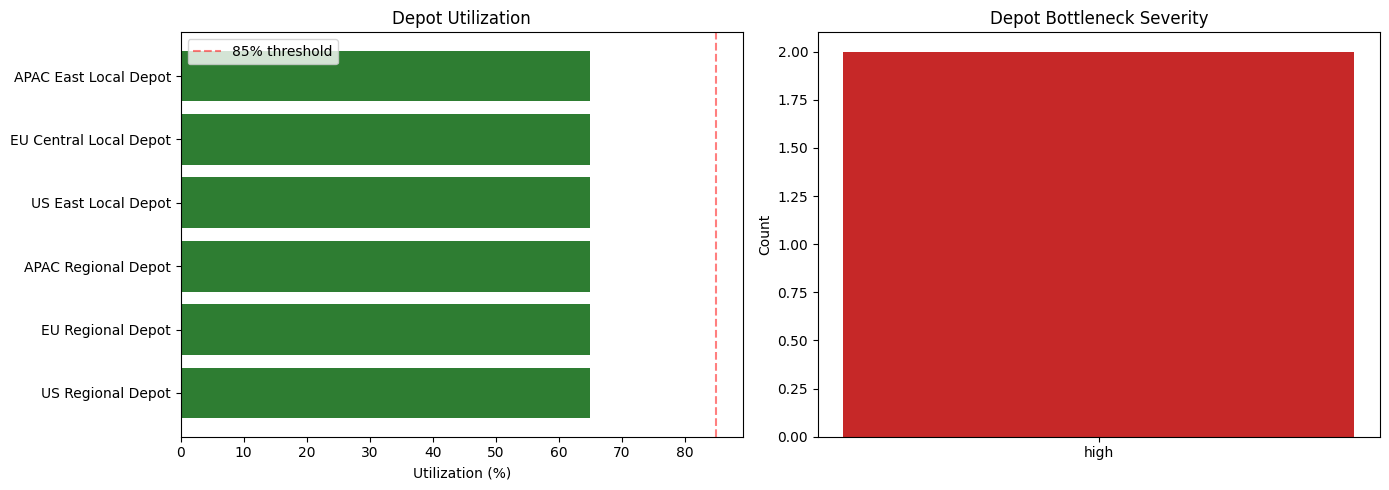

In [18]:
# Plot: Depot utilization and bottlenecks
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Depot utilization bars
if depot_plan.depot_calendars:
    names = [cal.location_name for cal in depot_plan.depot_calendars]
    utils = [cal.utilization_pct for cal in depot_plan.depot_calendars]
    bar_colors = ["#C62828" if u > 85 else "#F57F17" if u > 65 else "#2E7D32" for u in utils]
    ax1.barh(names, utils, color=bar_colors)
    ax1.axvline(85, color="red", linestyle="--", alpha=0.5, label="85% threshold")
    ax1.set_xlabel("Utilization (%)")
    ax1.set_title("Depot Utilization")
    ax1.legend()

# Bottleneck severity distribution
if depot_bottlenecks:
    sev_counts = {}
    for bn in depot_bottlenecks:
        sev = bn.get("severity", "unknown")
        sev_counts[sev] = sev_counts.get(sev, 0) + 1
    sev_colors = {"high": "#C62828", "medium": "#F57F17", "low": "#2E7D32"}
    ax2.bar(sev_counts.keys(), sev_counts.values(),
            color=[sev_colors.get(s, "gray") for s in sev_counts.keys()])
    ax2.set_ylabel("Count")
    ax2.set_title("Depot Bottleneck Severity")
else:
    ax2.text(0.5, 0.5, "No bottlenecks detected", ha="center", va="center",
             transform=ax2.transAxes, fontsize=14)
    ax2.set_title("Depot Bottleneck Severity")

plt.tight_layout()
plt.show()

---

## 8. Deep Dive: Plant Capacity Agent

The plant agent validates manufacturing capacity at the pilot plants.

| Desire | Priority | Description |
|--------|----------|-------------|
| `assess_plant_load` | 1 | Count DS/DP batches per plant |
| `assess_plant_capacity` | 2 | Compute reactor & formulation line capacity |
| `evaluate_campaigns` | 3 | Check campaign feasibility (< 85% utilization) |
| `identify_bottlenecks` | 4 | Flag capacity bottlenecks |
| `compile_plant_plan` | 5 | Build final plan with feasibility flag |

**Campaign utilization:**
- `total_days = sum(mfg_lead + qc_release + 3d changeover)` per product
- `available_days = reactor_lines * 22 * 12` (working days per year)
- `utilization = total_days / available_days * 100`
- Feasible if utilization < 85%

In [19]:
# Run plant capacity agent
plant_agent = PlantCapacityBDIAgent(demo_state)
plant_plan = plant_agent.run()

# Inspect beliefs
plant_load = plant_agent.belief_base.get("plant_load")
plant_capacity = plant_agent.belief_base.get("plant_capacity")
campaign_schedules = plant_agent.belief_base.get("campaign_schedules")
plant_bottlenecks = plant_agent.belief_base.get("bottlenecks")

print("=== Plant Load ===")
if plant_load:
    for plant_name, load in plant_load.items():
        print(f"  {plant_name}: ds_batches={load.get('ds_batches', 0)}, dp_batches={load.get('dp_batches', 0)}, products={load.get('products', [])}")

print(f"\n=== Campaign Schedules ===")
if campaign_schedules:
    for cs in campaign_schedules:
        print(f"  {cs.get('plant', '')}: {cs.get('total_campaign_days', 0)} days, "
              f"{cs.get('available_days', 0)} available, "
              f"utilization={cs.get('utilization_pct', 0):.1f}%, "
              f"feasible={cs.get('feasible', '?')}")

print(f"\n=== Bottlenecks ({len(plant_bottlenecks or [])}) ===")
for bn in (plant_bottlenecks or []):
    print(f"  [{bn.get('severity', '?'):6s}] {bn.get('plant', '')}: {bn.get('type', '')} - {bn.get('detail', '')}")

print(f"\nFeasible: {plant_plan.feasible}")
if plant_plan.adjustments:
    print("Adjustments:")
    for adj in plant_plan.adjustments:
        print(f"  - {adj}")

============================================================

  Plant Capacity (BDI Agent)

============================================================

Cycle 1:

Beliefs: supply_plan: loaded, 2 plants, 31 equipment_lines, 35 changeover_rules, materials: loaded

...

-> Done

All goals achieved in 4 cycle(s)

Result: feasible=False, 4 bottlenecks, 1 adjustments

[OK] BDI plant_capacity completed

=== Plant Load ===
  Springfield Pilot Plant: ds_batches=156, dp_batches=226, products=[]
  Basel Pilot Plant: ds_batches=76, dp_batches=181, products=[]

=== Campaign Schedules ===
  Springfield Pilot Plant: 0 days, 0 available, utilization=0.0%, feasible=False
  Basel Pilot Plant: 0 days, 0 available, utilization=0.0%, feasible=False

=== Bottlenecks (4) ===
  [medium] Springfield Pilot Plant:  - 8 DS products on 2 reactors (4.0 per reactor)
  [medium] Springfield Pilot Plant:  - 8 DP products on 2 formulation lines
  [medium] Basel Pilot Plant:  - 7 DS products on 2 reactors (3.5 per reactor)
  [high  ] Basel Pilot Plant:  - 7 DP products on 1 formulation lines

Feasible: False
Adjustments:
  - Capacity constraint at Basel Pilot Plant - formulation_lines: 7 DP products on 1 formulation lines


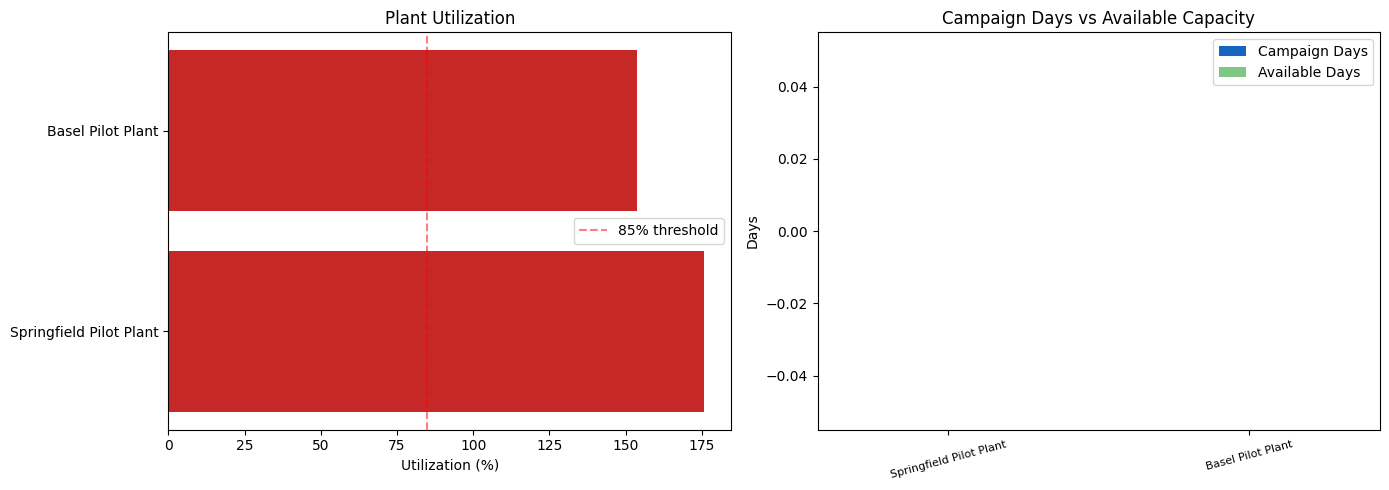

In [20]:
# Plot: Plant utilization and campaign feasibility
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plant utilization
if plant_plan.plant_calendars:
    names = [cal.location_name for cal in plant_plan.plant_calendars]
    utils = [cal.utilization_pct for cal in plant_plan.plant_calendars]
    bar_colors = ["#C62828" if u > 85 else "#F57F17" if u > 65 else "#2E7D32" for u in utils]
    ax1.barh(names, utils, color=bar_colors)
    ax1.axvline(85, color="red", linestyle="--", alpha=0.5, label="85% threshold")
    ax1.set_xlabel("Utilization (%)")
    ax1.set_title("Plant Utilization")
    ax1.legend()

# Campaign days breakdown
if campaign_schedules:
    camp_names = [cs.get("plant", f"Plant {i}") for i, cs in enumerate(campaign_schedules)]
    campaign_days = [cs.get("total_campaign_days", 0) for cs in campaign_schedules]
    available_days = [cs.get("available_days", 0) for cs in campaign_schedules]
    x = np.arange(len(camp_names))
    width = 0.35
    ax2.bar(x - width/2, campaign_days, width, label="Campaign Days", color="#1565C0")
    ax2.bar(x + width/2, available_days, width, label="Available Days", color="#81C784")
    ax2.set_xticks(x)
    ax2.set_xticklabels(camp_names, fontsize=8, rotation=15)
    ax2.set_ylabel("Days")
    ax2.set_title("Campaign Days vs Available Capacity")
    ax2.legend()

plt.tight_layout()
plt.show()

---

## 9. Replanning Loop

The BDI pipeline's unique feature is **iterative replanning**. When either the depot
or plant capacity agent reports infeasibility, the pipeline:

1. Collects adjustment recommendations from infeasible capacity plans
2. Stores them as `state._bdi_capacity_constraints`
3. Clears all agent outputs
4. Re-runs all 5 agents (supply agent reads constraints to adjust batches)

Up to `MAX_REPLANS = 2` retries are allowed.

In [21]:
# Run a fresh pipeline and capture replanning info
replan_state = SharedState()
replan_state.load_from_dir(DATA_DIR)

# Track feasibility across attempts
feasibility_log = []

for attempt in range(1 + MAX_REPLANS):
    print(f"\n{'='*60}")
    print(f"  Pipeline Attempt {attempt + 1}")
    print(f"{'='*60}")

    # Check for injected constraints
    constraints = getattr(replan_state, "_bdi_capacity_constraints", None)
    if constraints:
        print(f"  Capacity constraints injected: {len(constraints)}")
        for c in constraints[:3]:
            print(f"    - {c}")

    # Run all 5 agents
    for agent_name, agent_cls in BDI_AGENT_SEQUENCE:
        agent = agent_cls(replan_state)
        agent.run()

    # Check feasibility
    depot_ok = replan_state.depot_capacity_plan and replan_state.depot_capacity_plan.feasible
    plant_ok = replan_state.plant_capacity_plan and replan_state.plant_capacity_plan.feasible

    feasibility_log.append({
        "attempt": attempt + 1,
        "depot_feasible": depot_ok,
        "plant_feasible": plant_ok,
        "overall_feasible": depot_ok and plant_ok,
        "batch_count": len(replan_state.supply_plan.batches) if replan_state.supply_plan else 0,
        "constraints_count": len(constraints) if constraints else 0,
    })

    if depot_ok and plant_ok:
        print(f"\n  [FEASIBLE] Pipeline converged on attempt {attempt + 1}")
        break

    if attempt < MAX_REPLANS:
        # Collect adjustments
        new_constraints = []
        if not depot_ok and replan_state.depot_capacity_plan:
            new_constraints.extend(replan_state.depot_capacity_plan.adjustments)
        if not plant_ok and replan_state.plant_capacity_plan:
            new_constraints.extend(replan_state.plant_capacity_plan.adjustments)
        replan_state._bdi_capacity_constraints = new_constraints

        # Clear outputs for re-run
        replan_state.demand_plan = None
        replan_state.portfolio_plan = None
        replan_state.supply_plan = None
        replan_state.depot_capacity_plan = None
        replan_state.plant_capacity_plan = None
        print(f"  [INFEASIBLE] Replanning with {len(new_constraints)} constraints...")
    else:
        print(f"  [INFEASIBLE] Max replanning attempts reached, proceeding anyway.")

# Summary table
print(f"\n{'='*60}")
print("=== Replanning Summary ===")
display(pd.DataFrame(feasibility_log))


  Pipeline Attempt 1


============================================================

  Demand Review (BDI Agent)

============================================================

Derived: 15 trial-to-FG mappings

...

All goals achieved in 4 cycle(s)

Result: feasible=False, 4 bottlenecks, 1 adjustments

[OK] BDI plant_capacity completed

  [INFEASIBLE] Max replanning attempts reached, proceeding anyway.

=== Replanning Summary ===


,attempt,depot_feasible,plant_feasible,overall_feasible,batch_count,constraints_count
0,1,False,False,False,669,0
1,2,False,False,False,669,3
2,3,False,False,False,669,3


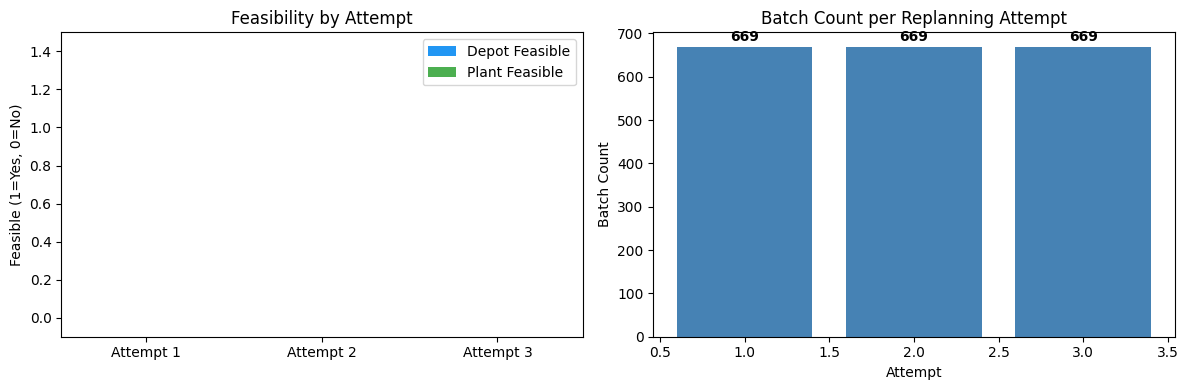

In [22]:
# Plot: Replanning convergence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

attempts = [r["attempt"] for r in feasibility_log]

# Feasibility status per attempt
depot_status = [1 if r["depot_feasible"] else 0 for r in feasibility_log]
plant_status = [1 if r["plant_feasible"] else 0 for r in feasibility_log]
x = np.arange(len(attempts))
width = 0.35
ax1.bar(x - width/2, depot_status, width, label="Depot Feasible", color="#2196F3")
ax1.bar(x + width/2, plant_status, width, label="Plant Feasible", color="#4CAF50")
ax1.set_xticks(x)
ax1.set_xticklabels([f"Attempt {a}" for a in attempts])
ax1.set_ylabel("Feasible (1=Yes, 0=No)")
ax1.set_title("Feasibility by Attempt")
ax1.legend()
ax1.set_ylim(-0.1, 1.5)

# Batch count per attempt
batch_counts = [r["batch_count"] for r in feasibility_log]
ax2.bar(attempts, batch_counts, color="steelblue")
ax2.set_xlabel("Attempt")
ax2.set_ylabel("Batch Count")
ax2.set_title("Batch Count per Replanning Attempt")
for i, v in enumerate(batch_counts):
    ax2.text(attempts[i], v + max(batch_counts) * 0.02, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

---

## 10. Method Comparison: BDI vs LLM vs RL

All three pipelines produce the same Pydantic output types and write to the same
`SharedState` blackboard. The key differences are in reasoning approach, requirements,
and interpretability.

| Feature | LLM | RL | BDI |
|---------|-----|-----|-----|
| **Requires API key** | Yes | No | No |
| **Requires training** | No | Yes (500K steps) | No |
| **Number of agents** | 5 | 4 | 5 |
| **Reasoning style** | Multi-turn tool-calling | Single forward pass (PPO) | Rule-based cycle |
| **Iterative replanning** | No | No | Yes (max 2 retries) |
| **Interpretability** | Moderate (reasoning text) | Low (neural weights) | High (full belief/goal trace) |
| **Latency** | High (API calls) | Low (inference) | Low (local computation) |
| **Cost** | Per-token API cost | One-time training | Free |
| **Customization** | Prompt engineering | Reward shaping | Rule editing |

In [23]:
# Summary of BDI pipeline output
print("=" * 60)
print("  BDI Pipeline Output Summary")
print("=" * 60)

dp = final_state.demand_plan
pp = final_state.portfolio_plan
sp = final_state.supply_plan
dcp = final_state.depot_capacity_plan
pcp = final_state.plant_capacity_plan

if dp:
    print(f"\n  Demand Plan:")
    print(f"    Total kit demand:  {dp.total_kit_demand:,}")
    print(f"    Site demand records: {len(dp.site_demands)}")
    print(f"    Trials with demand: {len(dp.demand_by_trial)}")
    print(f"    Horizon: {dp.horizon_start} to {dp.horizon_end}")

if pp:
    print(f"\n  Portfolio Plan:")
    print(f"    Ranked trials:     {len(pp.ranked_trials)}")
    print(f"    Conflicts:         {len(pp.conflicts)}")
    print(f"    Synergies:         {len(pp.synergies)}")
    print(f"    Allocations:       {len(pp.resource_allocations)}")

if sp:
    print(f"\n  Supply Plan:")
    print(f"    Batches:           {len(sp.batches)}")
    print(f"    Shortfall alerts:  {len(sp.shortfall_alerts)}")
    print(f"    Horizon: {sp.horizon_start} to {sp.horizon_end}")

if dcp:
    print(f"\n  Depot Capacity Plan:")
    print(f"    Calendars:         {len(dcp.depot_calendars)}")
    print(f"    Feasible:          {dcp.feasible}")
    print(f"    Adjustments:       {len(dcp.adjustments)}")

if pcp:
    print(f"\n  Plant Capacity Plan:")
    print(f"    Calendars:         {len(pcp.plant_calendars)}")
    print(f"    Feasible:          {pcp.feasible}")
    print(f"    Adjustments:       {len(pcp.adjustments)}")

print(f"\n  Pipeline events:     {len(final_state.events)}")
print("=" * 60)

  BDI Pipeline Output Summary

  Demand Plan:
    Total kit demand:  33,005
    Site demand records: 2627
    Trials with demand: 15
    Horizon: 2026-01-01 to 2029-10-01

  Portfolio Plan:
    Ranked trials:     15
    Conflicts:         5
    Synergies:         5
    Allocations:       5

  Supply Plan:
    Batches:           669
    Shortfall alerts:  0
    Horizon: 2025-08-22 to 2027-03-04

  Depot Capacity Plan:
    Calendars:         6
    Feasible:          False
    Adjustments:       2

  Plant Capacity Plan:
    Calendars:         2
    Feasible:          False
    Adjustments:       1

  Pipeline events:     30


---

## 11. CLI Reference

The BDI pipeline can be run entirely from the command line:

```bash
# Generate synthetic data
python -m csc.cli generate --trials 15 --sites 30 --seed 42

# Run the full BDI pipeline
python -m csc.cli run --all --method bdi

# Run a single BDI agent
python -m csc.cli run --agent demand_review --method bdi

# Run with custom data/output directories
python -m csc.cli run --all --method bdi --data-dir path/to/data --output-dir path/to/reports
```

Configuration via `.env`:

| Variable | Default | Description |
|----------|---------|-------------|
| `CSC_METHOD` | `llm` | Pipeline method: `llm`, `rl`, or `bdi` |
| `CSC_MAX_AGENT_TURNS` | `20` | Max turns per agent (LLM only) |

**No API keys or trained models needed** — just set `CSC_METHOD=bdi` and run.